# Immunogenicity tool test: Testing setttings for tools: NetMHCpan_BA
Author: Rebecka Antonsson\
Version: 1 (02-03-2026)

# Notebook explanation
Notebook to calculate the scores of the outputs from the tool BioPhi(OASis) with different settings.

Settings tested are:\
\
netMHCpan_BA_peplength8\
netMHCpan_BA_peplength9\
netMHCpan_BA_peplength10\
netMHCpan_BA_peplength11\
netMHCpan_BA_peplength12\
netMHCpan_BA_peplength13\
netMHCpan_BA_peplength14\

The only difference is the sliding windoww lengtht that is used when testing each sequence. There are seven different window sizes called peptidelength.


netmhcpan_el percentile:The percentile rank generated by comparing the peptide's IC50/score against those of a set of random peptides from SWISSPROT database.  Probability that the peptide will be natrually present on MHC-1.
IEDB themself recomend using a threshold of <=1% to cover most of the immune response
Here the score is calculated as nr of rows with netMHCpan percentile <=1, divided by total number of rows. Meaning that higher number indicated higher immunogenicity. The score can be described as the percentage of MHC-peptides that have a netMHCpan percentile below 1

For each tool_output with different settings a ranking from 1 to 37 will be done, each antibody will hence be given a number 1 to 37
This ranking will be compared to the known/ clinically determined immunigenecity ranking of the antibodies. The clinical immunigenecity ranking is based on anti-drug antibody (ADA) data. The two nanobodies will be held outside the ranking since they have risk of behaving differently, and special intreset is taken in how the tool perform at prediction those.

For each setting three measurments on how good they perform will be calculated:
    1. Mean absolute rank error (MARE) for antibodies
    2. Spearman rank correlation
    3. Mean absolute rank error for the two nanobodies

1. MARE is just the absolute difference between the known rank of the antibody and the predicted rank
2. Spearman rank correlation is a statistical test that can compare two lists of ranking and tell how well they align. 1 is a perfect correlation
0 means no relation between the two variables (no correlation, random) and -1 is a perfect reversed correlation (very bad).
3. Same calculation as for 1, but separated from the rest. Here a separate ranking where the 2 nanobodies are included are performed, hence antobodies and nanobodies get a number 1 to 39 and the MARE for the nanobodies is calculated. 

In [1]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [2]:
# Load the tool outputs with the different setttings, store each in a separate pandas DataFrame
netMHCpan_BA_peplength8 = pd.read_csv("tool_outputs/netMHCpan_BA_peplength8_02_03_2026.csv") 
netMHCpan_BA_peplength9 = pd.read_csv("tool_outputs/netMHCpan_BA_peplength9_02_03_2026.csv")
netMHCpan_BA_peplength10 = pd.read_csv("tool_outputs/netMHCpan_BA_peplength10_02_03_2026.csv")
netMHCpan_BA_peplength11 = pd.read_csv("tool_outputs/netMHCpan_BA_peplength11_02_03_2026.csv")
netMHCpan_BA_peplength12 = pd.read_csv("tool_outputs/netMHCpan_BA_peplength12_02_03_2026.csv")
netMHCpan_BA_peplength13 = pd.read_csv("tool_outputs/netMHCpan_BA_peplength13_02_03_2026.csv")
netMHCpan_BA_peplength14 = pd.read_csv("tool_outputs/netMHCpan_BA_peplength14_02_03_2026.csv")

# Then also load the sequence table for each tool output. 
# This is because in the tool output of the scores each antibody sequence has just been given an number (1-39)
# With the sequence table I can map the antibody name back to the number it was given


seq_table_netMHCpan_BA_peplength8 = pd.read_csv("tool_outputs/seq_table_netMHCpan_BA_peplength8_02_03_2026.csv")
seq_table_netMHCpan_BA_peplength9 = pd.read_csv("tool_outputs/seq_table_netMHCpan_BA_peplength9_02_03_2026.csv")
seq_table_netMHCpan_BA_peplength10 = pd.read_csv("tool_outputs/seq_table_netMHCpan_BA_peplength10_02_03_2026.csv")
seq_table_netMHCpan_BA_peplength11 = pd.read_csv("tool_outputs/seq_table_netMHCpan_BA_peplength11_02_03_2026.csv")
seq_table_netMHCpan_BA_peplength12 = pd.read_csv("tool_outputs/seq_table_netMHCpan_BA_peplength12_02_03_2026.csv")
seq_table_netMHCpan_BA_peplength13 = pd.read_csv("tool_outputs/seq_table_netMHCpan_BA_peplength13_02_03_2026.csv")
seq_table_netMHCpan_BA_peplength14 = pd.read_csv("tool_outputs/seq_table_netMHCpan_BA_peplength14_02_03_2026.csv")

In [3]:
# Create dictionary with all df names too be able to loop through them
all_dfs = {
"netMHCpan_BA_peplength8": netMHCpan_BA_peplength8,
"netMHCpan_BA_peplength9": netMHCpan_BA_peplength9,
"netMHCpan_BA_peplength10": netMHCpan_BA_peplength10,
"netMHCpan_BA_peplength11": netMHCpan_BA_peplength11,
"netMHCpan_BA_peplength12": netMHCpan_BA_peplength12,
"netMHCpan_BA_peplength13": netMHCpan_BA_peplength13,
"netMHCpan_BA_peplength14": netMHCpan_BA_peplength14
}

seq_tables = {
    "netMHCpan_BA_peplength8": seq_table_netMHCpan_BA_peplength8,
    "netMHCpan_BA_peplength9": seq_table_netMHCpan_BA_peplength9,
    "netMHCpan_BA_peplength10": seq_table_netMHCpan_BA_peplength10,
    "netMHCpan_BA_peplength11": seq_table_netMHCpan_BA_peplength11,
    "netMHCpan_BA_peplength12": seq_table_netMHCpan_BA_peplength12,
    "netMHCpan_BA_peplength13": seq_table_netMHCpan_BA_peplength13,
    "netMHCpan_BA_peplength14": seq_table_netMHCpan_BA_peplength14
}

In [4]:
# Sanity check
# Check so that all dataframes have all the 39 antibodies and the 27 alleles
for df in all_dfs.values():
    # check if unique values in seq # column is 39)
    if df['seq #'].nunique()==39:
        continue
    else:
        print(f'{df, "does not have 39 antibodies/nanobodies"}')
    # check if number of unique valies in HLA allele column is 27)
    if df['allele'].nunique()==27:
        continue
    else:
        print(f'{df,"does not have 27 HLA alleles"}')

In [5]:
# Clean dataframes a bit, and instert the correct antibody names
for key in all_dfs:
    df = all_dfs[key]
    seq_table = seq_tables[key] 

    # Insert the sequence names (Antibody names) into the dataframe with scores, map by seq #, which exists in both dataframes
    df = df.merge(seq_table[['seq #', 'sequence name']], how='left')

    # Rename the column "sequence name" to "Antibody", 
    df.rename(columns={'sequence name': 'Antibody'}, inplace=True)

    # remove the two columns called seq # from the calc_rank_table
    df = df.drop(columns=['seq #'])

    # Place the anotbody columns as the first column beacuse its easier to read

    # Remove the last column and save it as a variable
    last_col = df.pop(df.columns[-1])
    # Insert the column as the first column
    df.insert(0, last_col.name, last_col)

    all_dfs[key] = df

In [6]:
all_dfs["netMHCpan_BA_peplength8"].head()

,Antibody,peptide,start,end,peptide length,allele,peptide index,median binding percentile,netmhcpan_ba core,netmhcpan_ba icore,netmhcpan_ba ic50,netmhcpan_ba percentile
0,SECUKINUMAB,YYIHYWYF,107,114,8,HLA-A*23:01,988,0.04,YYI-HYWYF,YYIHYWYF,14.01,0.04
1,NATALIZUMAB,DTYIHWVR,31,38,8,HLA-A*33:01,5788,0.04,DTY-IHWVR,DTYIHWVR,21.90,0.04
2,SECUKINUMAB,LTDYYIHY,104,111,8,HLA-A*01:01,985,0.04,LTDYYIH-Y,LTDYYIHY,54.37,0.04
3,ALEMTUZUMAB,RPSQTLSL,13,20,8,HLA-B*07:02,7998,0.05,RPS-QTLSL,RPSQTLSL,17.14,0.05
4,ALEMTUZUMAB,DFYMNWVR,31,38,8,HLA-A*33:01,8016,0.05,DFY-MNWVR,DFYMNWVR,32.04,0.05


Here the score is calculated as nr of rows with netMHCpan percentile <=1, divided by total number of rows. Meaning that higher number indicated higher immunogenicity. The score can be described as the percentage of MHC-peptides that have a netMHCpan percentile below 1

In [7]:
# Loop through all the dataframes, and calculate the percantage of rows that have netmhcpan_ba percentile below 1
# Overwrite the old dataframe and put the antibody name + the percent_immunogen as the columns 
for key, df in all_dfs.items():

    score_df = (
        df.assign(immunogenic=df['netmhcpan_ba percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('Antibody')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='percent_immunogen')
    )

    all_dfs[key] = score_df # overwrite the old df 

In [8]:
# For all the dataframes in the all_dfs dictionary loop through them and make a copy 
# without the two rows where Antibody = Caplacizumab or Vobarilizumab
# Put the new dataframes into a new dictionary called all_dfs_AB

# we need to do this because we don't want these two nanobodies to be ranked, 
# but we also don't want them to mess with the ranking of the other antibodies

all_dfs_AB = {}

for name, df in all_dfs.items():
    # make a new dictionary with a copy of the dataframes but without the two nanobodies
    all_dfs_AB[name + "_AB"] = df.loc[~df['Antibody'].isin(['Caplacizumab', 'Vobarilizumab'])].copy()

# Check so it worked
all_dfs_AB.keys()
all_dfs_AB["netMHCpan_BA_peplength8_AB"].tail()

,Antibody,percent_immunogen
33,SECUKINUMAB,0.422352
34,TILDRAKIZUMAB,0.342936
35,USTEKINUMAB,0.388973
36,VEDOLIZUMAB,0.294985
37,VISILIZUMAB,0.304414


In [9]:
# Now add a column to the all_dfs_AB dataframe called ranked by tool, where the percent_immonogen values are ranked from highest to lowest
# Highest means highest immunogenicity, so thats 37.
for df in all_dfs_AB.values():
    df['ranked_by_tool'] = df['percent_immunogen'].rank(ascending=True, method='average')

# Do the same for the df includning the two nanobodies
for df in all_dfs.values():
    df['ranked_by_tool'] = df['percent_immunogen'].rank(ascending=True, method='average')

In [10]:
# Load the ADA ranking
ADA_rank = {
'BEZLOTOXUMAB':1,
'VISILIZUMAB':2,
'OMALIZUMAB':3,
'EVOLOCUMAB':4,
'SECUKINUMAB':5,
'DENOSUMAB':6,
'IBALIZUMAB':7,
'OCRELIZUMAB':8,
'FREMANEZUMAB':9,
'BASILIXIMAB':10,
'PALIVIZUMAB':11,
'CANAKINUMAB':12,
'ECULIZUMAB':13,
'BRODALUMAB':14,
'MEPOLIZUMAB':15,
'GUSELKUMAB':16,
'RESLIZUMAB':17,
'ALIROCUMAB':18,
'GALCANEZUMAB':19,
'VEDOLIZUMAB':20,
'EFALIZUMAB':21,
'TILDRAKIZUMAB':22,
'USTEKINUMAB':23,
'DUPILUMAB':24,
'ERENUMAB':25,
'SARILUMAB':26,
'NATALIZUMAB':27,
'Caplacizumab':28,
'LANADELUMAB':29,
'BUROSUMAB':30,
'BENRALIZUMAB':31,
'ADALIMUMAB':32,
'IXEKIZUMAB':33,
'RITUXIMAB':34,
'INFLIXIMAB':35,
'GOLIMUMAB':36,
'Vobarilizumab':37,
'BOCOCIZUMAB':38,
'ALEMTUZUMAB':39
}

# create antoher dictionary where the two nanobdoies are removed 
ADA_rank_AB = {
'BEZLOTOXUMAB':1,
'VISILIZUMAB':2,
'OMALIZUMAB':3,
'EVOLOCUMAB':4,
'SECUKINUMAB':5,
'DENOSUMAB':6,
'IBALIZUMAB':7,
'OCRELIZUMAB':8,
'FREMANEZUMAB':9,
'BASILIXIMAB':10,
'PALIVIZUMAB':11,
'CANAKINUMAB':12,
'ECULIZUMAB':13,
'BRODALUMAB':14,
'MEPOLIZUMAB':15,
'GUSELKUMAB':16,
'RESLIZUMAB':17,
'ALIROCUMAB':18,
'GALCANEZUMAB':19,
'VEDOLIZUMAB':20,
'EFALIZUMAB':21,
'TILDRAKIZUMAB':22,
'USTEKINUMAB':23,
'DUPILUMAB':24,
'ERENUMAB':25,
'SARILUMAB':26,
'NATALIZUMAB':27,
'LANADELUMAB':28,
'BUROSUMAB':29,
'BENRALIZUMAB':30,
'ADALIMUMAB':31,
'IXEKIZUMAB':32,
'RITUXIMAB':33,
'INFLIXIMAB':34,
'GOLIMUMAB':35,
'BOCOCIZUMAB':36,
'ALEMTUZUMAB':37
}

In [11]:
# Add the ADA rank to the dfs
# AntiBody df
for df in all_dfs_AB.values():
    df['ADA_rank'] = df['Antibody'].map(ADA_rank_AB)

# Nanobody df
for df in all_dfs.values():
    df['ADA_rank'] = df['Antibody'].map(ADA_rank)

In [12]:
# Compute MARE for the AB dataframes

# Add a column called MARE, for each row add the value for the absolute difference between the ranked_by_tool and ADA_rank
for df in all_dfs_AB.values():
    df['MARE'] = (df['ranked_by_tool'] - df['ADA_rank']).abs()

# Do the same thing for the dataframes with the nanobodies
for df in all_dfs.values():
    df['MARE'] = df['ranked_by_tool'] - df['ADA_rank'] 

In [13]:
# Create a ranked_score_table df with coulmns, datadframe (with all df names from all_dfs_AB),
# The sum of MARE for each df, 
# The spearman rank correlation between ranked by tool and ADA rank,
# The MARE for Caplacizumab and Vobarilizumab
ranked_score_table = pd.DataFrame({
    'dataframe': list(all_dfs_AB.keys()),
    'sum_MARE': [df['MARE'].sum() for df in all_dfs_AB.values()],
    'spearmanr': [spearmanr(df['ranked_by_tool'], df['ADA_rank']).correlation for df in all_dfs_AB.values()],
    'spearmanr_pval': [spearmanr(df['ranked_by_tool'], df['ADA_rank']).pvalue for df in all_dfs_AB.values()],
    'Caplacizumab_MARE': [df.loc[df['Antibody'] == 'Caplacizumab', 'MARE'].values[0] for df in all_dfs.values()],
    'Vobarilizumab_MARE': [df.loc[df['Antibody'] == 'Vobarilizumab', 'MARE'].values[0] for df in all_dfs.values()]
    
})

# save the ranked_score_table as a csv file
ranked_score_table.to_csv('ranked_score_table.csv', index=False)
ranked_score_table

,dataframe,sum_MARE,spearmanr,spearmanr_pval,Caplacizumab_MARE,Vobarilizumab_MARE
0,netMHCpan_BA_peplength8_AB,517.0,-0.212118,0.207533,6.0,-36.0
1,netMHCpan_BA_peplength9_AB,452.0,-0.033551,0.843725,9.0,-21.0
2,netMHCpan_BA_peplength10_AB,446.0,-0.032837,0.847007,11.0,-29.0
3,netMHCpan_BA_peplength11_AB,480.0,-0.126600,0.455269,9.0,-33.0
4,netMHCpan_BA_peplength12_AB,502.0,-0.080493,0.635796,11.0,-36.0
5,netMHCpan_BA_peplength13_AB,558.0,-0.416217,0.010398,6.0,-28.0
6,netMHCpan_BA_peplength14_AB,508.0,-0.167852,0.320696,-26.0,0.0


Text(0.5, 1.0, 'netMHC I pan BA')

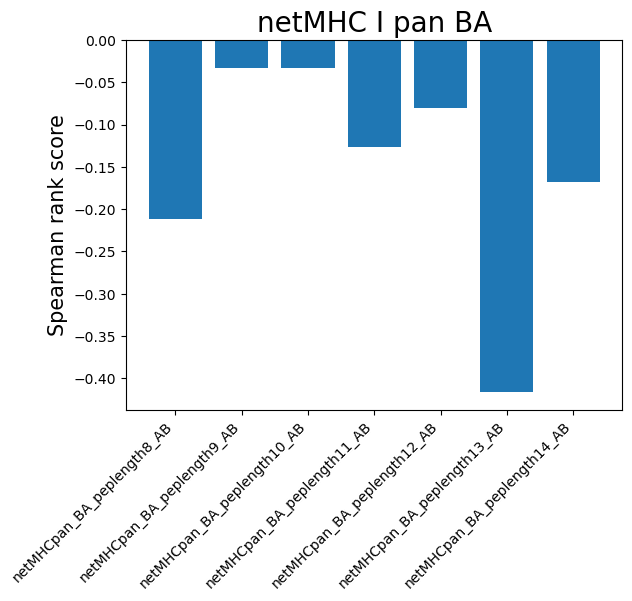

In [14]:
# plot spearman rank score for each setting
plt.bar(ranked_score_table['dataframe'], ranked_score_table['spearmanr'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Spearman rank score', size=15)
plt.title("netMHC I pan BA", size=20)